# QI-DMO: Quantum-Inspired Dwarf Mongoose Optimization for Cloud Task Scheduling
### A standalone notebook: how well QI-DMO schedules cloud tasks, and what each improvement changed

**What this notebook does**
* **Part 1 — Performance of QI-DMO.** QI-DMO is run on its own:
  * 7 benchmark problems (30–200 tasks, 30 runs each);
  * 5 large problems (500–5 000 tasks on 50 VMs, 10 runs each).

  For every problem you get the makespan in seconds (best, worst, mean ± SD), the gap to the theoretical lower bound,
  the energy in Wh, the run time and the convergence curve.
* **Part 2 — How we improved it.** The same problems are solved at each stage of the development:
  **DMO (original) → QI-DMO (quantum-inspired) → QI-DMO + swap move (two versions)**. A third problem set checks the
  versions on 80 problems that no earlier QI-DMO experiment used.
  * **The quantum-inspired step is a large, clear improvement.**
  * **The swap move gives mixed results for QI-DMO.** It helps on the large problems, but it is not an established
    improvement on 30–300-task problems. Part 2 shows exactly where it helps and where it does not.
* **Everything is saved** to a Google Drive folder:
  * every single run (CSV);
  * every table (CSV, plus one Excel file);
  * every figure (PNG);
  * a short summary (`summary.txt`).

**How to run in Google Colab**
1. Open the notebook in Colab (*File → Upload notebook*).
2. In **Settings** (Section 1), choose the mode:
   * `MODE = "quick"`: a short check;
   * `MODE = "full"`: all problems and runs.
3. Click *Runtime → Run all*, and allow access to Google Drive when Colab asks.
4. The results appear in **My Drive → `QI_DMO_results` → `<mode>_run`**.

**Run time.** Free Colab has 2 CPU cores, so the notebook runs 2 runs at a time there.
* **Quick mode:** 3.6 minutes measured with 2 processes on a 2.8 GHz Xeon; expect about 4–12 minutes on Colab.
* **Full mode:** the runs took 3.25 CPU-hours in total (the sum of the measured run times); with 2 processes on free Colab, expect roughly 2–4 hours.
* **Keep the browser tab open.** Free Colab stops idle sessions. If it disconnects, reconnect and click *Run all*
  again: finished runs are read back from Google Drive and skipped.

**About "quantum-inspired".** Everything runs on an ordinary CPU; no quantum computer is used.
* **Superposition.** Each task keeps a probability for every VM.
* **Measurement.** A schedule is obtained by sampling these probabilities.
* **Decoherence.** A small noise level keeps every VM possible, so the search does not freeze.
* **What this means.** These are quantum *ideas* used inside a classical algorithm. No quantum advantage is claimed.

**Units.** Task lengths are in MI (million instructions) and VM speeds in MIPS, so times (makespan) are in
**seconds**. Energy is in **Wh**. The *gap* is how much later a schedule finishes than the lower bound, in %.

## Section 1 — Settings
This is the only cell you normally need to change.

In [1]:
# =====================================================================================================
# SECTION 1 - SETTINGS (the only cell you normally need to edit)
# =====================================================================================================

# MODE sets how big the experiments are:
#   "quick" : a SUBSET of the full runs with exactly the same settings (fewer problems and runs; 500 and 1000 tasks
#             only for the large problems). Every quick run is identical to the same run in full mode, but the
#             averages use far fewer runs. Use it first to check that everything works.
#   "full"  : all problems and runs. It takes hours on free Colab, but every finished run is saved to Google Drive
#             at once, so an interrupted session can simply be resumed.
MODE = "full"

# Which parts to run (True = run, False = skip)
RUN_PART_1 = True   # Part 1: performance of QI-DMO on its own
RUN_PART_2 = True   # Part 2: how QI-DMO was improved, step by step

# Where to save the results
SAVE_TO_GOOGLE_DRIVE = True               # False: save only inside this Colab session (lost when it ends)
DRIVE_FOLDER_NAME = "QI_DMO_results"      # this folder is created inside "My Drive"
RUN_NAME = None                           # None -> "<MODE>_run"; give a new name (e.g. "full_run_2") for a fresh folder

# Number of runs executed in parallel. None = use every CPU core (free Colab has 2).
N_WORKERS = 4

## Section 2 — Setup: packages, Google Drive and the results folder
* Colab already has every package this notebook needs (NumPy, SciPy, pandas, Matplotlib); anything missing is installed.
* **Google Drive.** It is mounted, and the results folder is created, e.g. `My Drive/QI_DMO_results/quick_run`.
* **Running outside Colab.** The results go to a local folder with the same name.

In [2]:
# =====================================================================================================
# SECTION 2 - SETUP: packages, Google Drive, results folder
# =====================================================================================================
import sys, os, time, json, platform, subprocess
import importlib.util
import multiprocessing as mp

# Install a package only if it is missing (on Colab nothing needs installing)
for pkg in ["numpy", "scipy", "pandas", "matplotlib"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import numpy as np
import scipy
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display

IN_COLAB = "google.colab" in sys.modules      # True when this notebook runs inside Google Colab

# ---- Google Drive: mount it and choose the base folder for all results --------------------------
if SAVE_TO_GOOGLE_DRIVE and IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")                         # Colab asks for permission the first time
    BASE_DIR = os.path.join("/content/drive/MyDrive", DRIVE_FOLDER_NAME)
else:
    if SAVE_TO_GOOGLE_DRIVE:
        print("Not running in Google Colab: results are saved to a local folder instead of Google Drive.")
    BASE_DIR = os.path.abspath(DRIVE_FOLDER_NAME)

# ---- One sub-folder per run: re-running with the same RUN_NAME resumes it ------------------------
RUN_DIR = os.path.join(BASE_DIR, RUN_NAME or f"{MODE}_run")
os.makedirs(RUN_DIR, exist_ok=True)
N_WORKERS = N_WORKERS or os.cpu_count() or 1

print(f"Python {platform.python_version()} | numpy {np.__version__} | scipy {scipy.__version__} | "
      f"pandas {pd.__version__} | matplotlib {matplotlib.__version__}")
print(f"Running in Colab: {IN_COLAB} | CPU cores: {os.cpu_count()} | parallel workers: {N_WORKERS}")
print(f"MODE = {MODE!r}. All results of this run are saved in:\n  {RUN_DIR}")

Not running in Google Colab: results are saved to a local folder instead of Google Drive.
Python 3.11.15 | numpy 2.2.6 | scipy 1.15.3 | pandas 2.3.1 | matplotlib 3.10.3
Running in Colab: False | CPU cores: 4 | parallel workers: 4
MODE = 'full'. All results of this run are saved in:
  /home/user/QCCProject/results/notebook_runs/QI_DMO_results/full_run


## Section 3 — The cloud task scheduling problem
* **The problem.** There are $n$ independent tasks (cloudlets) with lengths $L_i$ in MI, and $m$ virtual machines with
  speeds $S_j$ in MIPS.
* **Execution time.** Task $i$ on VM $j$ takes $ET_{ij} = L_i / S_j$ seconds.
* **A schedule** assigns every task to one VM: an integer vector $a$ with $a_i \in \{0,\dots,m-1\}$.
* **Makespan.** The objective is the time at which the last VM finishes: $\max_j \sum_{i:a_i=j} ET_{ij}$. Lower is better.
* **Lower bound.** No schedule can finish before $\max(\sum L / \sum S,\ \max L / \max S)$. The tighter "preemptive"
  bound `lower_bound_pmtn` is also computed. The *gap* is how far above the lower bound a schedule is, in %.
* **Energy.** A linear power model (idle and busy power per VM) gives the energy of a schedule in Wh.
* **Problem generator.** Task lengths are uniform, lognormal (heavy-tailed) or bimodal. VM speeds have high, low or no
  heterogeneity. Everything is seeded, so every run can be reproduced exactly.

The code cells of Sections 3 and 4 are copied unchanged, function by function, from the project's tested modules
(`qi_core.py`, `qi_quantum.py`, `qi_dynamic.py`). They contain only what this notebook needs.

In [3]:
# =====================================================================================================
# SECTION 3 - PROBLEM MODEL (verbatim from qi_core.py)
#   CloudInstance - tasks, VMs, execution-time matrix, lower bounds
#   make_instance - seeded random problem generator
#   Objective     - makespan / energy of a schedule; counts evaluations (the budget unit)
# =====================================================================================================
import numpy as np, time, hashlib
from dataclasses import dataclass, field

@dataclass
class CloudInstance:
    """Independent tasks (cloudlets) on heterogeneous VMs: the standard CloudSim-style model."""
    task_len: np.ndarray      # MI per task
    vm_mips: np.ndarray       # MIPS per VM
    vm_p_idle: np.ndarray     # W
    vm_p_max: np.ndarray      # W
    name: str = ""
    et: np.ndarray = field(init=False)   # execution-time matrix n x m: et[i, j] = task_len[i] / vm_mips[j]
    def __post_init__(self):
        self.et = self.task_len[:, None] / self.vm_mips[None, :]
    @property
    def n(self): return len(self.task_len)
    @property
    def m(self): return len(self.vm_mips)
    def lower_bound(self):
        # Q||Cmax lower bound: max(total work / total speed, largest task on fastest VM)
        return max(self.task_len.sum() / self.vm_mips.sum(), self.task_len.max() / self.vm_mips.max())
    def lower_bound_pmtn(self):
        """Tighter valid bound: the optimal PREEMPTIVE makespan Q|pmtn|Cmax (Liu & Yang 1974; Horvath, Lam & Sethi 1977;
        Gonzalez & Sahni 1978) = max( max_{k<K} P_k / S_k , P_n / S_K ), K = min(n, m), P_k = sum of the k largest task
        lengths, S_k = sum of the k fastest speeds. Always >= lower_bound(); used for the V5 'gap2' columns."""
        P = np.cumsum(np.sort(self.task_len)[::-1]); S = np.cumsum(np.sort(self.vm_mips)[::-1]); K = min(self.n, self.m)
        prefix = (P[:K - 1] / S[:K - 1]).max() if K > 1 else 0.0
        return max(prefix, P[-1] / S[K - 1])
    def copy_with(self, task_len=None, vm_mips=None, vm_p_idle=None, vm_p_max=None, name=None):
        return CloudInstance(self.task_len if task_len is None else task_len, self.vm_mips if vm_mips is None else vm_mips,
                             self.vm_p_idle if vm_p_idle is None else vm_p_idle, self.vm_p_max if vm_p_max is None else vm_p_max,
                             name or self.name)

def sample_task_lengths(rng, n_tasks, task_dist):
    if task_dist == "uniform":
        return rng.uniform(1000, 10000, n_tasks)
    if task_dist == "lognormal":
        return rng.lognormal(np.log(3000), 1.0, n_tasks)
    if task_dist == "bimodal":          # 80% small, 20% big (heavy tail typical of cloud traces)
        big = rng.random(n_tasks) < 0.2
        return np.where(big, rng.uniform(20000, 40000, n_tasks), rng.uniform(500, 3000, n_tasks))
    if task_dist == "identical":
        return np.full(n_tasks, 5000.0)
    raise ValueError(task_dist)

def sample_vm_speeds(rng, n_vms, hetero):
    if hetero == "high":
        return rng.choice([250, 500, 1000, 1500, 2000], n_vms).astype(float) + rng.uniform(-50, 50, n_vms)
    if hetero == "low":
        return rng.uniform(900, 1100, n_vms)
    if hetero == "none":
        return np.full(n_vms, 1000.0)
    raise ValueError(hetero)

def make_instance(n_tasks, n_vms, seed, task_dist="uniform", hetero="high", name=None):
    rng = np.random.default_rng(seed)
    L = sample_task_lengths(rng, n_tasks, task_dist)
    S = sample_vm_speeds(rng, n_vms, hetero)
    p_max = 100.0 + 0.1 * S             # W, grows with speed
    p_idle = 0.6 * p_max
    return CloudInstance(L, S, p_idle, p_max, name or f"n{n_tasks}_m{n_vms}_{task_dist}_{hetero}_s{seed}")

class Objective:
    """Evaluate integer assignment vectors (task -> VM). Counts evaluations (the budget unit for every optimizer).
    kind='makespan_migration' (V5, H8): makespan x (1 + lam * voluntary migrations / eligible tasks), where a migration is
    an eligible task (mig_mask: persistent, VM survived) assigned differently from the deployed reference schedule `ref`."""
    def __init__(self, inst: CloudInstance, kind="makespan", w_energy=0.3, ref=None, mig_mask=None, lam=0.0):
        self.inst, self.kind, self.w_energy = inst, kind, w_energy
        if kind == "makespan_migration":
            self.ref = np.asarray(ref); self.mig_mask = np.asarray(mig_mask, bool); self.lam = float(lam)
            self.n_eligible = max(1, int(self.mig_mask.sum()))
        self.n_evals = 0
        self._ar = np.arange(inst.n)
        rr = self._ar % inst.m                      # round-robin reference schedule for scaling
        self.ms_ref, self.e_ref = self._raw(rr)
    def _raw(self, assign):
        et_sel = self.inst.et[self._ar, assign]
        loads = np.bincount(assign, weights=et_sel, minlength=self.inst.m)
        ms = loads.max()
        energy = (self.inst.vm_p_idle * ms + (self.inst.vm_p_max - self.inst.vm_p_idle) * loads).sum() / 3600.0  # Wh
        return ms, energy
    def __call__(self, assign):
        self.n_evals += 1
        ms, en = self._raw(assign)
        if self.kind == "makespan":
            return ms
        if self.kind == "makespan_energy":
            return (1 - self.w_energy) * ms / self.ms_ref + self.w_energy * en / self.e_ref
        if self.kind == "makespan_migration":
            return ms * (1.0 + self.lam * self.migrations(assign) / self.n_eligible)
        raise ValueError(self.kind)
    def migrations(self, assign):
        return int(((np.asarray(assign) != self.ref) & self.mig_mask).sum())
    def details(self, assign):
        ms, en = self._raw(assign)
        d = {"makespan": ms, "energy_Wh": en}
        if self.kind == "makespan_migration": d["migrations"] = self.migrations(assign)
        return d

## Section 4 — The algorithms
**4a. Tools.** `Tracker` records run diagnostics (switched off in the experiments; it does not change the results).
**`critical_exchange` is the swap move.**
* **What it does.** It takes a task from the *busiest* VM and swaps it with a shorter task on another VM, or moves it
  if no shorter task exists.
* **Why it can help.** QI-DMO samples every task independently, so it almost never produces this correlated two-task
  change. The move clearly helped QI-MRFO; for QI-DMO the results are mixed (Part 2).

In [4]:
# =====================================================================================================
# SECTION 4a - TOOLS (verbatim from qi_core.py)
#   Tracker            - run diagnostics (optional; switched off in the experiments for speed)
#   critical_exchange  - THE SWAP MOVE on the busiest VM
# =====================================================================================================

class Tracker:
    """Records per-iteration statistics common to all optimizers (used to test the MECHANISM, not just the score).
    With `inst` given (V5), two extra diagnostics are recorded per candidate: whether the schedule was ever evaluated
    before in the run (global duplicate; 'wasted' only counts parent-identical candidates) and whether the candidate
    moves a task off its reference schedule's critical VM (a necessary condition for a strict makespan improvement).
    They only read the candidates, so the optimizers' behaviour is unchanged."""
    def __init__(self, n, m, inst=None):
        self.n, self.m = n, m
        self.evals, self.best, self.mean, self.div_ham = [], [], [], []
        self.wasted = self.neutral = self.improving = self.worse = 0
        self.move_sizes = []
        self.gb_improvements = 0
        self.dup_global = self.touch_crit = self.x_cands = self.x_improving = 0
        self._et = None if inst is None else inst.et
        self._seen = set(); self._ar = np.arange(n)
        self.flags = []            # per candidate: 1 = improving, 0 = not (used for late-run improvement rates)
        self.t0 = time.time()
    def candidate(self, parent_assign, child_assign, f_parent, f_child):
        diff = parent_assign != child_assign
        changed = int(diff.sum())
        self.move_sizes.append(changed)
        if changed == 0: self.wasted += 1
        elif f_child < f_parent - 1e-12: self.improving += 1
        elif abs(f_child - f_parent) <= 1e-12: self.neutral += 1
        else: self.worse += 1
        if self._et is not None:
            self.flags.append(int(changed > 0 and f_child < f_parent - 1e-12))
            self._seen.add(hashlib.blake2b(parent_assign.tobytes(), digest_size=8).digest())
            key = hashlib.blake2b(child_assign.tobytes(), digest_size=8).digest()   # deterministic (no PYTHONHASHSEED salt)
            if key in self._seen: self.dup_global += 1
            else: self._seen.add(key)
            loads = np.bincount(parent_assign, weights=self._et[self._ar, parent_assign], minlength=self.m)
            crit = loads >= loads.max() * (1 - 1e-12)
            self.touch_crit += int((diff & crit[parent_assign]).any())
    def snapshot(self, n_evals, assigns, fits, best):
        self.evals.append(n_evals); self.best.append(best); self.mean.append(float(np.mean(fits)))
        A = np.asarray(assigns); P = len(A)
        if P > 1:
            ham = 0.0
            for i in range(P - 1):
                ham += (A[i + 1:] != A[i]).sum()
            self.div_ham.append(ham / (P * (P - 1) / 2) / self.n)
        else:
            self.div_ham.append(0.0)
    def summary(self):
        tot = max(1, self.wasted + self.neutral + self.improving + self.worse)
        return {"wasted_frac": self.wasted / tot, "neutral_frac": self.neutral / tot,
                "improving_frac": self.improving / tot, "worse_frac": self.worse / tot,
                "mean_move_size": float(np.mean(self.move_sizes)) if self.move_sizes else 0.0,
                "gb_impr_per_1k": 1000.0 * self.gb_improvements / max(1, self.evals[-1] if self.evals else 1),
                "runtime_s": time.time() - self.t0}
    def summary_v5(self):
        """V5 diagnostics (needs Tracker(..., inst)): global duplicates, critical-VM touches, exchange-move counts,
        late-half improvement rate and the budget fraction at which the global best last improved."""
        tot = max(1, len(self.move_sizes))
        ev, bs = np.asarray(self.evals, float), np.asarray(self.best, float)
        drops = np.where(np.diff(bs) < 0)[0]
        last = ev[drops[-1] + 1] / ev[-1] if len(drops) and ev[-1] > 0 else 0.0
        fl = np.asarray(self.flags)
        return {"dup_global_frac": self.dup_global / tot, "touch_crit_frac": self.touch_crit / tot,
                "x_frac": self.x_cands / tot, "x_success": self.x_improving / max(1, self.x_cands),
                "late_improving_frac": float(fl[len(fl) // 2:].mean()) if len(fl) > 1 else 0.0,
                "last_gb_impr_frac": float(last)}

def critical_exchange(inst, a, rng):
    """V5 critical exchange move (CXM). t is drawn uniformly from the tasks on the critical VM(s) of schedule a;
    u uniformly from the tasks on other VMs that are SHORTER than t (necessary for the exchange to lower the critical
    load); t and u swap VMs. If no shorter task exists elsewhere, t is relocated to a uniformly random other VM.
    Returns (new_a, t, u), u = -1 for a relocation. Shared by QI-MRFO and the GA so that both get the identical operator."""
    n, m = inst.n, inst.m
    new = a.copy()
    if m < 2: return new, -1, -1
    loads = np.bincount(a, weights=inst.et[np.arange(n), a], minlength=m)
    crit = loads >= loads.max() * (1 - 1e-12)
    T = np.flatnonzero(crit[a])
    t = T[rng.integers(len(T))]; b = a[t]
    U = np.flatnonzero((a != b) & (inst.task_len < inst.task_len[t]))
    if len(U):
        u = U[rng.integers(len(U))]
        new[t], new[u] = a[u], b
        return new, t, u
    v = rng.integers(m - 1); v += int(v >= b)
    new[t] = v
    return new, t, -1

**4b. The original DMO** (Dwarf Mongoose Optimization; Agushaka, Ezugwu and Abualigah, 2022). The mongoose group
forages in three phases: the *alpha group* searches around a chosen alpha, *scouts* look for new sleeping mounds, and
*babysitters* are replaced when the group stops improving.
* **Rounding.** DMO is a continuous algorithm. To schedule tasks, each task's position is rounded to a VM number, as
  is usual in the cloud-scheduling literature.
* **Why this is a problem.** One DMO move then changes about half of all task assignments at once (35–61 % in the
  project's benchmark), which is close to drawing a new random schedule.

In [5]:
# =====================================================================================================
# SECTION 4b - THE ORIGINAL DMO WITH ROUNDING (verbatim from qi_core.py)
#   decode / _init_pop - continuous positions -> VM numbers, random start
# =====================================================================================================

def decode(x, m):
    """continuous position in [0, m) -> integer VM index (floor encoding used by most swarm schedulers)"""
    return np.clip(np.floor(x), 0, m - 1).astype(int)

# All optimizers share the signature (inst, obj, budget, P, seed, ...) and return a dict with best_f, best_assign,
# tracker and a 'state' that can be passed back as init_state for warm-started (dynamic) re-optimization.
def _init_pop(rng, P, n, m):
    return rng.uniform(0, m, (P, n))

def run_dmo(inst, obj, budget, P=30, seed=0, n_baby_sitter=3, peep=2.0, track=True, greedy_next=False, init_state=None):
    """Dwarf Mongoose Optimization, faithful to the authors' MATLAB code as reproduced in MEALPY OriginalDMOA.
    greedy_next=True replaces the unconditional 'next mongoose position' move by a greedy one (MEALPY DevDMOA style)."""
    rng = np.random.default_rng(seed); n, m = inst.n, inst.m
    tr = Tracker(n, m, inst)
    X = _init_pop(rng, P, n, m) if init_state is None else np.clip(init_state["X"].copy(), 0, m - 1e-9)
    A = decode(X, m); F = np.array([obj(a) for a in A])
    C = np.zeros(P); tau = -np.inf; L = np.round(0.6 * n * n_baby_sitter)
    g = F.argmin(); gbF, gbA = F[g], A[g].copy()
    max_iter = max(1, (budget - P) // (3 * P))
    tr.snapshot(obj.n_evals, A, F, gbF)
    def clip(x): return np.clip(x, 0, m - 1e-9)
    for it in range(1, max_iter + 1):
        if obj.n_evals + 3 * P + n_baby_sitter > budget: break         # never exceed the evaluation budget
        CF = (1.0 - it / max_iter) ** (2.0 * it / max_iter)
        fi = np.exp(-F / F.mean()); prob = fi / fi.sum()
        for i in range(P):                                             # alpha-group foraging
            alpha = rng.choice(P, p=prob)
            k = rng.choice([k for k in range(P) if k not in (i, alpha)])
            phi = (peep / 2) * rng.uniform(-1, 1, n)
            new = clip(X[alpha] + phi * (X[alpha] - X[k]))
            a_new = decode(new, m); f = obj(a_new)
            if track: tr.candidate(A[i], a_new, F[i], f)
            if f < F[i]: X[i], A[i], F[i] = new, a_new, f
            else: C[i] += 1
            if f < gbF: gbF, gbA = f, a_new.copy(); tr.gb_improvements += 1
        SM = np.zeros(P)
        for i in range(P):                                             # scout group + sleeping mound
            k = rng.choice([k for k in range(P) if k != i])
            phi = (peep / 2) * rng.uniform(-1, 1, n)
            new = clip(X[i] + phi * (X[i] - X[k]))
            a_new = decode(new, m); f = obj(a_new)
            if track: tr.candidate(A[i], a_new, F[i], f)
            SM[i] = (f - F[i]) / max(f, F[i])
            if f < F[i]: X[i], A[i], F[i] = new, a_new, f
            else: C[i] += 1
            if f < gbF: gbF, gbA = f, a_new.copy(); tr.gb_improvements += 1
        for i in range(n_baby_sitter):                                 # babysitter exchange
            if C[i] >= L:
                X[i] = rng.uniform(0, m, n); A[i] = decode(X[i], m); F[i] = obj(A[i]); C[i] = 0
                if F[i] < gbF: gbF, gbA = F[i], A[i].copy(); tr.gb_improvements += 1
        new_tau = SM.mean()
        for i in range(P):                                             # next mongoose position
            phi = (peep / 2) * rng.uniform(-1, 1, n)
            if new_tau > tau: new = X[i] - CF * phi * rng.random() * (X[i] - SM[i])
            else:             new = X[i] + CF * phi * rng.random() * (X[i] - SM[i])
            tau = new_tau
            new = clip(new); a_new = decode(new, m); f = obj(a_new)
            if track: tr.candidate(A[i], a_new, F[i], f)
            if (not greedy_next) or f < F[i]: X[i], A[i], F[i] = new, a_new, f
            if f < gbF: gbF, gbA = f, a_new.copy(); tr.gb_improvements += 1
        tr.snapshot(obj.n_evals, A, F, gbF)
    return {"best_f": gbF, "best_assign": gbA, "tracker": tr, "state": {"X": X}}

**4c. The quantum-inspired mechanism.**
* **Register per task.** Each task keeps a *register*: an amplitude vector with one entry per VM. Its probabilities
  (amplitude² under the Born rule) give the chance that the task goes to each VM.
* **Measurement** samples a VM for every task and so gives a concrete schedule, which is then evaluated.
* **Decoherence** is a small uniform mixing of strength γ = c / n. It keeps every VM possible for every task.
* **`collapse_rows`** sets the registers of the two swapped tasks to the swapped outcome (used by the swap move).

**4d. QI-DMO.** DMO's three phases act on the registers instead of rounded positions: the alpha group moves towards
the alpha's *measured schedule*, scouts move away from another mongoose's register, and babysitters are reset by
full decoherence.
* **Why it helps.** A move changes far fewer tasks than with rounding (22–28 % in the project's benchmark).
* **The swap move.** It was first developed for QI-MRFO. For this notebook it was added to QI-DMO, in two versions:
  * **In every phase** (`exchange=1.0, exchange_phases="all"`): the QI-MRFO move unchanged, on every measured
    candidate (test H14).
  * **In improving phases** (`exchange=0.1, exchange_phases="greedy"`): only in the alpha-group and scout phases, which
    keep a candidate only if it is better, with probability 0.1 (test H15). Both settings were chosen on development
    problems before the test.
  * **Why two versions.** QI-DMO's third phase (next position) keeps every candidate, even a worse one. There, a swap
    that makes the schedule worse is kept too.
* **Settings in all experiments.** c = 0.25, population 30, 20 000 evaluations per run.

In [6]:
# =====================================================================================================
# SECTION 4c - QUANTUM-INSPIRED MECHANISM (verbatim from qi_quantum.py)
#   born_probs / probs  - register -> probabilities (Born rule or classical linear version)
#   measure             - sample one schedule from the registers
#   depolarise / purity - decoherence channel and how 'collapsed' a register is
#   collapse_rows       - measurement back-action used by the swap move
# =====================================================================================================

def born_probs(psi):
    p = psi ** 2
    return p / p.sum(1, keepdims=True)

def renormalise(psi, m):
    nrm = np.sqrt((psi ** 2).sum(1, keepdims=True))
    bad = (nrm[:, 0] < 1e-12)
    psi = psi / np.where(nrm < 1e-12, 1.0, nrm)
    if bad.any():
        psi[bad] = 1.0 / np.sqrt(m)
    return psi

def probs(psi, mode):
    if mode.startswith("born"):
        return born_probs(psi)
    p = np.clip(psi, 0, None); return p / np.maximum(p.sum(1, keepdims=True), 1e-300)

def measure(psi, rng, mode):
    """Sample one schedule from the register set (Born rule or linear probabilities)."""
    p = probs(psi, mode)
    u = rng.random(len(p))
    a = (np.cumsum(p, 1) < u[:, None]).sum(1)
    return np.minimum(a, p.shape[1] - 1)

def basis_state(assign, m):
    E = np.zeros((len(assign), m)); E[np.arange(len(assign)), assign] = 1.0
    return E          # a one-hot row is both a unit amplitude vector and a probability vector

def project(psi, m, mode):
    """Bring an updated register set back to a valid state."""
    if mode == "born_signed":
        return renormalise(psi, m)
    if mode == "born_abs":
        return renormalise(np.abs(psi), m)
    p = np.clip(psi, 0, None); s = p.sum(1, keepdims=True)
    return np.where(s > 1e-12, p / np.where(s > 1e-12, s, 1.0), 1.0 / m)

def purity(psi, mode):
    return (probs(psi, mode) ** 2).sum(1)            # per task; 1 = collapsed, 1/m = uniform

def depolarise(psi, gamma, m, mode):
    """Depolarising channel: p <- (1-gamma) p + gamma/m ; signs kept for signed amplitudes."""
    if gamma <= 0: return psi
    if mode.startswith("born"):
        p2 = (1 - gamma) * born_probs(psi) + gamma / m
        return np.sign(psi + (psi == 0)) * np.sqrt(p2)
    return (1 - gamma) * psi + gamma / m

def uniform_state(n, m, mode):
    return np.full((n, m), 1.0 / np.sqrt(m)) if mode.startswith("born") else np.full((n, m), 1.0 / m)

def collapse_rows(psi, rows, outcomes, gamma, m, mode):
    """Measurement back-action (V5): the registers `rows` collapse onto the measured VMs `outcomes`, then pass through the
    same depolarising floor as every candidate register (so a collapsed row keeps purity < 1 when gamma > 0)."""
    psi = psi.copy()
    psi[rows] = depolarise(basis_state(np.asarray(outcomes), m), gamma, m, mode)
    return psi

In [7]:
# =====================================================================================================
# SECTION 4d - QI-DMO (verbatim from qi_quantum.py)
#   run_qidmo(instance, objective, budget, P=population, seed=..., decoherence=c/n, exchange=swap probability, ...)
#   returns {'best_f': best makespan, 'best_assign': best schedule, 'tracker': diagnostics, 'state': registers}
# =====================================================================================================

# ----------------------------------------------------------------------------------------------
# QI-DMO: DMO dynamics (MATLAB/MEALPY-faithful) on amplitude registers
# ----------------------------------------------------------------------------------------------
def run_qidmo(inst, obj, budget, P=30, seed=0, n_baby_sitter=3, peep=2.0, mode="born_signed",
              gamma_reset=1.0, decoherence=0.0, attractor="basis", greedy_next=False, track=True, init_state=None,
              exchange=0.0, exchange_phases="all"):
    """decoherence: per-candidate depolarising strength gamma (0 = V1); gamma_reset: babysitter channel strength;
    attractor: 'basis' (alpha peeps its measured schedule) or 'register' (alpha's superposition state).
    exchange>0 (V5, hypothesis H14): the swap move of QI-MRFO (H5) transferred unchanged to QI-DMO. With this probability
    a measured candidate of the three search phases (alpha group, scouts, next position) additionally exchanges a task of
    its critical VM with a shorter task on another VM (qi_core.critical_exchange), and the pair's registers collapse onto
    that outcome. The babysitter reset is a restart, not a search move, and is left unchanged.
    exchange_phases (V5, H15): "all" = the three search phases (H14); "greedy" = only the alpha-group and scout phases,
    whose candidates are kept only if they improve, as every QI-MRFO candidate is. The next-position phase keeps every
    candidate, so there a worsening swap would be kept too (the post-hoc explanation of H14)."""
    if exchange_phases not in ("all", "greedy"): raise ValueError(exchange_phases)
    rng = np.random.default_rng(seed); n, m = inst.n, inst.m
    tr = Tracker(n, m, inst); tr.purity = []
    if init_state is None:
        Psi = np.stack([uniform_state(n, m, mode) for _ in range(P)])
    else:
        Psi = init_state["Psi"].copy(); P = len(Psi)
    A = np.stack([measure(Psi[i], rng, mode) for i in range(P)]); F = np.array([obj(a) for a in A])
    C = np.zeros(P); tau = -np.inf; L = np.round(0.6 * n * n_baby_sitter)
    g = F.argmin(); gbF, gbA = F[g], A[g].copy()
    max_iter = max(1, (budget - obj.n_evals) // (3 * P))
    def snap():
        tr.snapshot(obj.n_evals, A, F, gbF); tr.purity.append(float(np.mean([purity(Psi[i], mode).mean() for i in range(P)])))
    snap()
    dec = lambda psi: depolarise(psi, decoherence, m, mode)
    def xmeasure(new, a_new):
        # H14: correlated exchange on top of the product-state measurement; no extra random draw when exchange == 0
        if exchange <= 0 or rng.random() >= exchange: return new, a_new, False
        a_x, tt, uu = critical_exchange(inst, a_new, rng)
        rows = [tt] if uu < 0 else [tt, uu]
        return collapse_rows(new, rows, a_x[rows], decoherence, m, mode), a_x, True
    def xtrack(xm, f, f_parent):
        if xm: tr.x_cands += 1; tr.x_improving += int(f < f_parent - 1e-12)
    for it in range(1, max_iter + 1):
        if obj.n_evals + 3 * P + n_baby_sitter > budget: break         # never exceed the evaluation budget
        CF = (1.0 - it / max_iter) ** (2.0 * it / max_iter)
        fi = np.exp(-F / F.mean()); prob = fi / fi.sum()
        # --- alpha-group foraging: candidate = alpha's peep perturbed by mongoose k
        for i in range(P):
            alpha = rng.choice(P, p=prob)
            k = rng.choice([k for k in range(P) if k not in (i, alpha)])
            phi = (peep / 2) * rng.uniform(-1, 1, (n, 1))
            E = basis_state(A[alpha], m) if attractor == "basis" else Psi[alpha]
            new = dec(project(E + phi * (E - Psi[k]), m, mode))
            a_new = measure(new, rng, mode)
            new, a_new, xm = xmeasure(new, a_new)
            f = obj(a_new)
            if track: tr.candidate(A[i], a_new, F[i], f); xtrack(xm, f, F[i])
            if f < F[i]: Psi[i], A[i], F[i] = new, a_new, f
            else: C[i] += 1
            if f < gbF: gbF, gbA = f, a_new.copy(); tr.gb_improvements += 1
        # --- scout group + sleeping mound
        SM = np.zeros(P)
        for i in range(P):
            k = rng.choice([k for k in range(P) if k != i])
            phi = (peep / 2) * rng.uniform(-1, 1, (n, 1))
            new = dec(project(Psi[i] + phi * (Psi[i] - Psi[k]), m, mode))
            a_new = measure(new, rng, mode)
            new, a_new, xm = xmeasure(new, a_new)
            f = obj(a_new)
            if track: tr.candidate(A[i], a_new, F[i], f); xtrack(xm, f, F[i])
            SM[i] = (f - F[i]) / max(f, F[i])
            if f < F[i]: Psi[i], A[i], F[i] = new, a_new, f
            else: C[i] += 1
            if f < gbF: gbF, gbA = f, a_new.copy(); tr.gb_improvements += 1
        # --- babysitter exchange = decoherence channel of strength gamma_reset (1 = full reset, classical DMO)
        for i in range(n_baby_sitter):
            if C[i] >= L:
                Psi[i] = depolarise(Psi[i], gamma_reset, m, mode); A[i] = measure(Psi[i], rng, mode); F[i] = obj(A[i]); C[i] = 0
                if F[i] < gbF: gbF, gbA = F[i], A[i].copy(); tr.gb_improvements += 1
        # --- next mongoose position (unconditional, CF-damped noise, as in the MATLAB code)
        new_tau = SM.mean()
        for i in range(P):
            phi = (peep / 2) * rng.uniform(-1, 1, (n, 1))
            if new_tau > tau: new = Psi[i] - CF * phi * rng.random() * (Psi[i] - SM[i])
            else:             new = Psi[i] + CF * phi * rng.random() * (Psi[i] - SM[i])
            tau = new_tau
            new = dec(project(new, m, mode))
            a_new = measure(new, rng, mode)
            xm = False
            if exchange_phases == "all": new, a_new, xm = xmeasure(new, a_new)
            f = obj(a_new)
            if track: tr.candidate(A[i], a_new, F[i], f); xtrack(xm, f, F[i])
            if (not greedy_next) or f < F[i]: Psi[i], A[i], F[i] = new, a_new, f
            if f < gbF: gbF, gbA = f, a_new.copy(); tr.gb_improvements += 1
        snap()
    return {"best_f": gbF, "best_assign": gbA, "tracker": tr, "state": {"Psi": Psi}}

## Section 5 — Experiment helpers
* **The versions of QI-DMO** compared in Part 2, and the function that runs one of them once.
* **A runner that saves every finished run to Google Drive at once** and skips runs that are already saved (resume).
* **Statistics.** The Wilcoxon signed-rank test (paired problems) and the Mann–Whitney U test (independent runs).
* **Plot style and the problem sets.**

In [8]:
# =====================================================================================================
# SECTION 5a - THE VERSIONS OF QI-DMO AND ONE RUN
# =====================================================================================================
# The development steps of QI-DMO, in order (Part 2 runs all of them, Part 1 only QI-DMO itself).
#   c        = decoherence strength of the quantum-inspired versions (gamma = c / number of tasks)
#   exchange = probability of the swap move
VARIANTS = {
    # the original algorithm, before our changes: continuous positions rounded to VM numbers
    "DMO (original)":  dict(fn=run_dmo),
    # step 1: quantum-inspired registers instead of rounding (decoherence c = 0.25, as in every project experiment)
    "QI-DMO":          dict(fn=run_qidmo, c=0.25),
    # step 2, first try (test H14): the swap move of QI-MRFO unchanged, on every measured candidate of all three
    # phases (probability 1)
    "QI-DMO + swap in every phase":      dict(fn=run_qidmo, c=0.25, exchange=1.0, exchange_phases="all"),
    # step 2, second version (test H15): the swap move only in the two phases that keep a candidate only if it is
    # better, with probability 0.1 (both chosen on the development problems: results/h15_selection.json)
    "QI-DMO + swap in improving phases": dict(fn=run_qidmo, c=0.25, exchange=0.1, exchange_phases="greedy"),
}
MAIN = "QI-DMO"                 # the algorithm of Part 1
STEPS = list(VARIANTS)            # the versions of Part 2, in development order
# The changes that Part 2 measures, as (version after the change, version before it)
CHANGES = [("QI-DMO", "DMO (original)"), ("QI-DMO + swap in every phase", "QI-DMO"),
           ("QI-DMO + swap in improving phases", "QI-DMO")]
SCATTER = [("QI-DMO + swap in every phase", "QI-DMO"), ("QI-DMO + swap in improving phases", "QI-DMO")]   # swap-move changes drawn problem by problem (Figure 2.2)
POPULATION = 30                   # population size (number of registers / individuals)


class RecordingObjective(Objective):
    # The normal objective (makespan) that also records the best makespan found so far after every 5 % of the
    # evaluation budget, for the convergence curves. It does not change the search in any way.
    def __init__(self, inst, budget, points=20):
        super().__init__(inst)
        self.marks = [budget * k // points for k in range(1, points + 1)]
        self.best, self.curve = np.inf, []

    def __call__(self, assign):
        f = super().__call__(assign)
        self.best = min(self.best, f)
        while len(self.curve) < len(self.marks) and self.n_evals >= self.marks[len(self.curve)]:
            self.curve.append(self.best)
        return f


def problem_name(n, m, dist, het):
    # e.g. "100 tasks, 10 VMs, uniform/high"
    return f"{n} tasks, {m} VMs, {dist}/{het}"


def run_one(job):
    # Run ONE version once on ONE problem and return one result row (makespan in seconds, gap in %, energy in Wh, ...)
    n, m, dist, het = job["problem"]
    inst = make_instance(n, m, seed=job["inst_seed"], task_dist=dist, hetero=het)   # the same problem for every version
    v = VARIANTS[job["variant"]]
    obj = RecordingObjective(inst, job["budget"])          # counts evaluations = the budget unit
    t0 = time.time()
    kw = {}
    if "c" in v:
        kw["decoherence"] = v["c"] / n                     # decoherence strength gamma = c / n
    for key in ("exchange", "exchange_phases"):            # probability of the swap move / where it is applied
        if key in v:
            kw[key] = v[key]
    result = v["fn"](inst, obj, job["budget"], P=POPULATION, seed=job["run_seed"], track=False, **kw)
    runtime = time.time() - t0
    makespan, energy = Objective(inst)._raw(result["best_assign"])   # exact makespan (s) and energy (Wh) of the result
    curve = obj.curve + [obj.best] * (len(obj.marks) - len(obj.curve))  # a run may stop a few evaluations early
    lb, lb_p = inst.lower_bound(), inst.lower_bound_pmtn()
    row = {"key": job["key"], "problem_set": job["problem_set"], "variant": job["variant"],
           "problem": problem_name(n, m, dist, het), "tasks": n, "vms": m, "task_lengths": dist, "vm_heterogeneity": het,
           "instance_seed": job["inst_seed"], "run_seed": job["run_seed"], "budget": job["budget"],
           "makespan_s": float(makespan), "energy_Wh": float(energy), "lower_bound_s": float(lb),
           "lower_bound_pmtn_s": float(lb_p), "gap_pct": float(100 * (makespan - lb) / lb),
           "gap_pmtn_pct": float(100 * (makespan - lb_p) / lb_p), "runtime_s": float(runtime),
           "evaluations": int(obj.n_evals)}
    for i, b in enumerate(curve, 1):                       # best makespan after 5 %, 10 %, ..., 100 % of the budget
        row[f"best_at_{5 * i:03d}pct_s"] = float(b)
    return row


def make_jobs(problem_set, variants, problems, inst_seeds, runs, budget):
    # All (version, problem, instance, run) combinations of one problem set
    jobs = []
    for prob in problems:
        for s in inst_seeds:
            for v in variants:
                for r in range(runs):
                    key = f"{problem_set}|{v}|{prob[0]}-{prob[1]}-{prob[2]}-{prob[3]}|inst{s}|run{r}|b{budget}"
                    jobs.append({"key": key, "problem_set": problem_set, "variant": v, "problem": tuple(prob),
                                 "inst_seed": s, "run_seed": r, "budget": budget})
    return jobs

In [9]:
# =====================================================================================================
# SECTION 5b - RUNNER THAT SAVES EVERY RUN TO GOOGLE DRIVE (and resumes after a disconnect)
# =====================================================================================================
def check_drive():
    # Stop with a clear message if Google Drive should be used but is not mounted (e.g. after the last cell unmounted
    # it): otherwise results would silently go to a temporary folder of this Colab session.
    if SAVE_TO_GOOGLE_DRIVE and IN_COLAB and not os.path.isdir("/content/drive/MyDrive"):
        raise RuntimeError("Google Drive is not mounted: run the Section 2 cell again, then re-run this cell.")


def read_runs(csv_name, jobs=None):
    # Read a saved results file back with exact floating-point values (None if it does not exist yet).
    # If `jobs` is given, keep only the runs of those jobs (so settings of an earlier run cannot mix in).
    path = os.path.join(RUN_DIR, csv_name)
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path, float_precision="round_trip").drop_duplicates("key", keep="last")
    if jobs is not None:
        df = df[df["key"].isin({j["key"] for j in jobs})].reset_index(drop=True)
    return df


def run_jobs(jobs, worker, csv_name):
    # Run all jobs in parallel. Each finished run is appended to RUN_DIR/csv_name immediately, so nothing is lost
    # if Colab disconnects. Runs already in that file are skipped: re-running a cell resumes the experiment.
    check_drive()
    path = os.path.join(RUN_DIR, csv_name)
    saved = read_runs(csv_name, jobs)
    done = set(saved["key"]) if saved is not None else set()
    todo = [j for j in jobs if j["key"] not in done]
    print(f"{csv_name}: {len(jobs)} runs in total | {len(done)} already saved | {len(todo)} to run on {N_WORKERS} worker(s)",
          flush=True)
    if todo:
        t0, step = time.time(), max(1, len(todo) // 10)
        pool = mp.get_context("fork").Pool(N_WORKERS) if (N_WORKERS > 1 and hasattr(os, "fork")) else None
        results = pool.imap_unordered(worker, todo) if pool else map(worker, todo)
        try:
            for i, row in enumerate(results, 1):
                pd.DataFrame([row]).to_csv(path, mode="a", header=not os.path.exists(path), index=False)   # save now
                if i % step == 0 or i == len(todo):
                    el = time.time() - t0
                    print(f"  {i}/{len(todo)} runs done | {el / 60:.1f} min elapsed | about {el / i * (len(todo) - i) / 60:.1f} min left",
                          flush=True)
        finally:
            if pool:                       # stop the worker processes (at once if the cell was interrupted)
                pool.terminate(); pool.join()
    return read_runs(csv_name, jobs)


ALL_TABLES = {}          # every table produced in this session (also written to one Excel file at the end)


def save_table(df, name, title=None):
    # Show a table in the notebook and save it as RUN_DIR/<name>.csv
    df.to_csv(os.path.join(RUN_DIR, name + ".csv"))
    ALL_TABLES[name] = df
    if title:
        print(title)
    display(df)


def wilcoxon(diff):
    # Two-sided Wilcoxon signed-rank test on paired differences (p-value)
    from scipy import stats
    d = np.asarray(diff, float); d = d[d != 0]
    return float(stats.wilcoxon(d).pvalue) if len(d) >= 2 else float("nan")


def p_text(p):
    # A p-value as text with 2 significant digits, so that a tiny p shows as e.g. 1.1e-13 and not as 0.0
    return "-" if p != p else f"{p:.2g}"


def holm(pvalues):
    # Holm-Bonferroni correction when several tests are done together
    p = np.asarray(pvalues, float); order = np.argsort(p); adj = np.empty_like(p); running = 0.0
    for rank, idx in enumerate(order):
        running = max(running, min(1.0, (len(p) - rank) * p[idx])); adj[idx] = running
    return adj


def mann_whitney(a, b):
    # Two-sided Mann-Whitney U test for two independent sets of runs (p-value)
    from scipy import stats
    a, b = np.asarray(a, float), np.asarray(b, float)
    if len(a) < 2 or len(b) < 2:
        return float("nan")
    return float(stats.mannwhitneyu(a, b, alternative="two-sided").pvalue)


def performance_table(df):
    # One row per problem: makespan statistics over the runs (s), gap (%), energy (Wh) and run time (s)
    g = df.groupby("problem", sort=False)
    t = pd.DataFrame({"tasks": g.tasks.first(), "VMs": g.vms.first(), "runs": g.size(),
                      "lower bound (s)": g.lower_bound_s.first(), "makespan mean (s)": g.makespan_s.mean(),
                      "makespan SD (s)": g.makespan_s.std(ddof=1).fillna(0.0), "best (s)": g.makespan_s.min(),
                      "worst (s)": g.makespan_s.max(), "gap to lower bound (%)": g.gap_pct.mean(),
                      "energy (Wh)": g.energy_Wh.mean(), "run time per run (s)": g.runtime_s.mean()})
    return t.round(3)

In [10]:
# =====================================================================================================
# SECTION 5c - PLOT STYLE (one consistent, colour-blind-checked palette for every figure)
# =====================================================================================================
from matplotlib.ticker import FuncFormatter
PERCENT = FuncFormatter(lambda v, _: f"{v:g} %")          # axis labels such as "1 %", "10 %", "100 %"
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7"]
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
plt.rcParams.update({"font.size": 9, "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "xtick.color": MUTED,
                     "ytick.color": MUTED, "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
                     "savefig.facecolor": SURFACE, "text.color": INK})


def style(ax, title, xlabel, ylabel):
    ax.set_title(title, loc="left", fontsize=10, color=INK)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.grid(True, color=GRID, linewidth=0.8); ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)


def save_figure(fig, name):
    # Save a figure as RUN_DIR/<name> (PNG) and show it
    fig.savefig(os.path.join(RUN_DIR, name), dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [11]:
# =====================================================================================================
# SECTION 5d - PROBLEMS AND EXPERIMENT SIZES FOR THE TWO MODES
# =====================================================================================================
# Benchmark problems: (tasks, VMs, task-length distribution, VM heterogeneity); problem seed 1
BENCHMARK = [(30, 5, "uniform", "high"), (50, 10, "bimodal", "high"), (100, 10, "uniform", "high"),
             (50, 10, "uniform", "none"), (200, 20, "uniform", "high"), (100, 10, "lognormal", "low"),
             (60, 8, "bimodal", "none")]
# Unseen problems: 8 problem types x 10 problems each (instance seeds 801-810: the fresh problems of the pre-registered swap-move test H15)
UNSEEN_TYPES = [(80, 8, "uniform", "high"), (150, 15, "uniform", "high"), (300, 30, "uniform", "high"),
                (100, 10, "bimodal", "high"), (200, 10, "bimodal", "none"), (120, 12, "lognormal", "high"),
                (60, 12, "uniform", "low"), (100, 20, "lognormal", "low")]
UNSEEN_SEEDS = list(range(801, 811))
# Large problems: 500 to 5000 tasks on 50 VMs; problem seed 1
LARGE = [(n, 50, "uniform", "high") for n in [500, 1000, 1500, 2000, 5000]]

# "full"  = every problem and run.
# "quick" = a subset of the same runs: same budgets, seeds and settings; fewer problems, runs and sizes.
EXPERIMENT_SIZES = {
    "quick": dict(
        benchmark=dict(problems=[BENCHMARK[0], BENCHMARK[2], BENCHMARK[4]], inst_seeds=[1], runs=3, budget=20000),
        unseen=dict(problems=[UNSEEN_TYPES[0], UNSEEN_TYPES[3], UNSEEN_TYPES[5]], inst_seeds=UNSEEN_SEEDS[:2], runs=1,
                    budget=20000),
        large=dict(problems=LARGE[:2], inst_seeds=[1], runs=2, budget=20000),
    ),
    "full": dict(
        benchmark=dict(problems=BENCHMARK, inst_seeds=[1], runs=30, budget=20000),
        unseen=dict(problems=UNSEEN_TYPES, inst_seeds=UNSEEN_SEEDS, runs=2, budget=20000),
        large=dict(problems=LARGE, inst_seeds=[1], runs=10, budget=20000),
    ),
}
SIZES = EXPERIMENT_SIZES[MODE]
CSV = {"benchmark": "benchmark_runs.csv", "unseen": "unseen_runs.csv", "large": "large_runs.csv"}


def jobs_for(problem_set, variants):
    # every run of one problem set for the given versions, in the size of the current MODE
    cfg = SIZES[problem_set]
    return make_jobs(problem_set, variants, cfg["problems"], cfg["inst_seeds"], cfg["runs"], cfg["budget"])


# Save the settings of this run next to the results (for reproducibility)
with open(os.path.join(RUN_DIR, "settings.json"), "w") as f:
    json.dump({"mode": MODE, "sizes": SIZES, "population": POPULATION, "workers": N_WORKERS,
               "python": platform.python_version(), "numpy": np.__version__, "started": time.strftime("%Y-%m-%d %H:%M:%S")},
              f, indent=1, default=str)
print(json.dumps(SIZES, indent=1, default=str))

{
 "benchmark": {
  "problems": [
   [
    30,
    5,
    "uniform",
    "high"
   ],
   [
    50,
    10,
    "bimodal",
    "high"
   ],
   [
    100,
    10,
    "uniform",
    "high"
   ],
   [
    50,
    10,
    "uniform",
    "none"
   ],
   [
    200,
    20,
    "uniform",
    "high"
   ],
   [
    100,
    10,
    "lognormal",
    "low"
   ],
   [
    60,
    8,
    "bimodal",
    "none"
   ]
  ],
  "inst_seeds": [
   1
  ],
  "runs": 30,
  "budget": 20000
 },
 "unseen": {
  "problems": [
   [
    80,
    8,
    "uniform",
    "high"
   ],
   [
    150,
    15,
    "uniform",
    "high"
   ],
   [
    300,
    30,
    "uniform",
    "high"
   ],
   [
    100,
    10,
    "bimodal",
    "high"
   ],
   [
    200,
    10,
    "bimodal",
    "none"
   ],
   [
    120,
    12,
    "lognormal",
    "high"
   ],
   [
    60,
    12,
    "uniform",
    "low"
   ],
   [
    100,
    20,
    "lognormal",
    "low"
   ]
  ],
  "inst_seeds": [
   801,
   802,
   803,
   804,
   805,
   

## Section 6 — Quick self-check (a few seconds)
Every version is run twice on a tiny problem. The check confirms that each one returns a valid schedule, respects its
evaluation budget and gives the same answer twice with the same seed.

In [12]:
# =====================================================================================================
# SECTION 6 - SELF-CHECK: valid schedules, budget respected, reproducible with the same seed
# =====================================================================================================
# Every version, twice, on a tiny problem (12 tasks, 3 VMs) with a budget of 600 evaluations
for _name in VARIANTS:
    _job = {"key": "check", "problem_set": "check", "variant": _name, "problem": (12, 3, "uniform", "high"),
            "inst_seed": 0, "run_seed": 0, "budget": 600}
    _r1, _r2 = run_one(_job), run_one(_job)
    assert _r1["evaluations"] <= 600, f"{_name} exceeded the budget"
    assert _r1["makespan_s"] == _r2["makespan_s"], f"{_name} is not reproducible"
    assert _r1["makespan_s"] >= _r1["lower_bound_s"] - 1e-9, f"{_name} beat the lower bound (impossible)"
    assert _r1["best_at_100pct_s"] == _r1["makespan_s"], f"{_name}: convergence curve does not end at the result"
print("Self-check passed: all", len(VARIANTS), "versions work.")

Self-check passed: all 4 versions work.


## Part 1 — Performance of QI-DMO
QI-DMO is run on its own, with the settings used in all project experiments (population 30, 20 000 evaluations per
run).

**The problems.**
* **Benchmark problems:** 7 problems with 30–200 tasks and 5–20 VMs, with different task-length distributions and VM
  heterogeneity. Full mode: 30 independent runs each.
* **Large problems:** 500, 1 000, 1 500, 2 000 and 5 000 tasks on 50 VMs. Full mode: 10 independent runs each.

**What you get.**
* **Tables 1.1 and 1.2.** Makespan in seconds (mean ± SD, best and worst run), the lower bound, the gap, the energy
  (Wh) and the run time of one run.
* **Figure 1.1.** Convergence: how the gap falls as the algorithm tries more schedules.
* **Figure 1.2.** The best schedule for the 100-task problem: how long every VM is busy. A good schedule keeps all VMs
  close to the lower bound.
* **Figure 1.3.** How the gap and the run time grow with the number of tasks.

**Output files.** `benchmark_runs.csv` and `large_runs.csv` (every run), `1_1_benchmark_performance.csv`,
`1_2_large_performance.csv`, `1_1_convergence.png`, `1_2_vm_finish_times.png` and `1_3_large_problems.png`.

benchmark_runs.csv: 210 runs in total | 210 already saved | 0 to run on 4 worker(s)


large_runs.csv: 50 runs in total | 50 already saved | 0 to run on 4 worker(s)


Table 1.1 - QI-DMO on the benchmark problems (makespan in seconds, energy in Wh)


,tasks,VMs,runs,lower bound (s),makespan mean (s),makespan SD (s),best (s),worst (s),gap to lower bound (%),energy (Wh),run time per run (s)
problem,,,,,,,,,,,
"30 tasks, 5 VMs, uniform/high",30,5,30,44.528,45.262,0.225,44.807,45.775,1.648,10.950,1.646
"50 tasks, 10 VMs, bimodal/high",50,10,30,25.107,29.635,1.614,26.676,32.498,18.036,16.876,1.824
"100 tasks, 10 VMs, uniform/high",100,10,30,47.061,48.925,0.244,48.436,49.393,3.963,29.156,2.355
"50 tasks, 10 VMs, uniform/none",50,10,30,28.387,30.421,0.386,29.667,31.121,7.166,16.449,2.457
"200 tasks, 20 VMs, uniform/high",200,20,30,60.832,66.317,1.229,64.252,69.429,9.017,67.608,4.939
"100 tasks, 10 VMs, lognormal/low",100,10,30,38.677,39.901,0.297,39.455,40.493,3.165,21.965,2.917
"60 tasks, 8 VMs, bimodal/none",60,8,30,52.936,57.824,1.591,55.488,60.972,9.233,24.830,2.399


Table 1.2 - QI-DMO on the large problems, 50 VMs (makespan in seconds, energy in Wh)


,tasks,VMs,runs,lower bound (s),makespan mean (s),makespan SD (s),best (s),worst (s),gap to lower bound (%),energy (Wh),run time per run (s)
problem,,,,,,,,,,,
"500 tasks, 50 VMs, uniform/high",500,50,10,53.376,90.728,7.897,78.263,103.796,69.977,216.983,13.733
"1000 tasks, 50 VMs, uniform/high",1000,50,10,101.376,143.550,4.939,136.984,152.517,41.602,372.723,26.016
"1500 tasks, 50 VMs, uniform/high",1500,50,10,164.783,324.004,8.916,305.677,335.853,96.625,753.661,38.377
"2000 tasks, 50 VMs, uniform/high",2000,50,10,231.547,478.838,9.569,463.754,493.628,106.800,1079.256,56.853
"5000 tasks, 50 VMs, uniform/high",5000,50,10,528.170,1402.891,26.926,1378.548,1450.768,165.614,3121.365,136.370


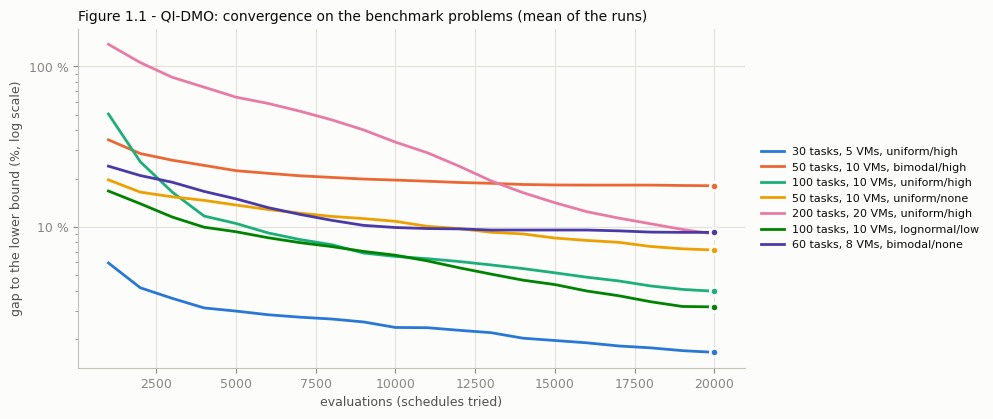

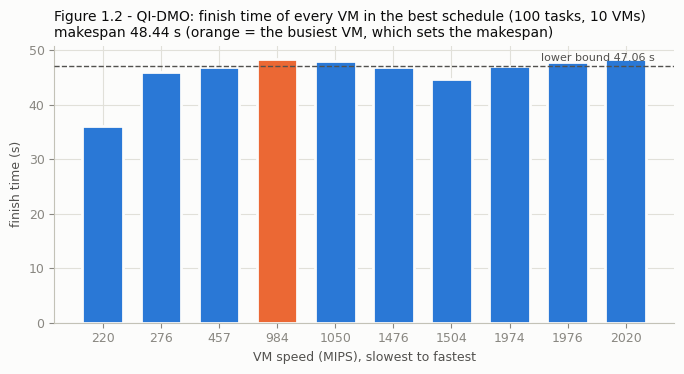

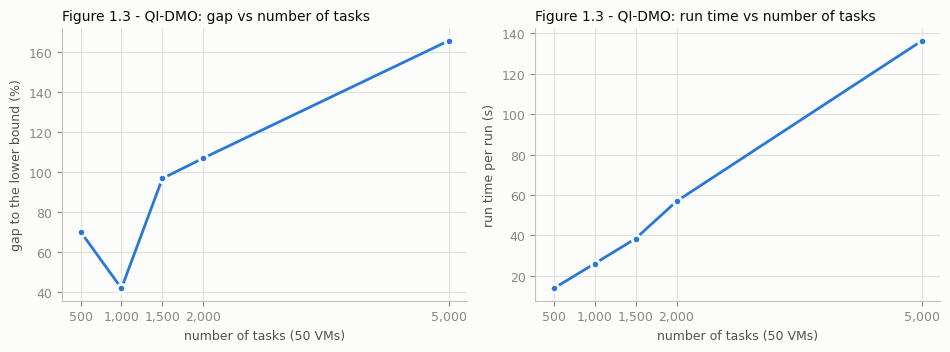

In [13]:
# =====================================================================================================
# PART 1 - PERFORMANCE OF QI-DMO ON ITS OWN
# =====================================================================================================
if RUN_PART_1:
    # ---- run QI-DMO on the benchmark problems and on the large problems (each run is saved at once) -------
    bench = run_jobs(jobs_for("benchmark", [MAIN]), run_one, CSV["benchmark"])
    large = run_jobs(jobs_for("large", [MAIN]), run_one, CSV["large"])

    # ---- Tables 1.1 and 1.2: one row per problem ------------------------------------------------------------
    save_table(performance_table(bench), "1_1_benchmark_performance",
               f"Table 1.1 - {MAIN} on the benchmark problems (makespan in seconds, energy in Wh)")
    save_table(performance_table(large), "1_2_large_performance",
               f"Table 1.2 - {MAIN} on the large problems, 50 VMs (makespan in seconds, energy in Wh)")

    # ---- Figure 1.1: convergence (gap to the lower bound vs evaluations, mean over the runs) -----------------
    cols = [c for c in bench.columns if c.startswith("best_at_")]
    frac = np.array([int(c[8:11]) for c in cols]) / 100               # 0.05, 0.10, ..., 1.00 of the budget
    fig, ax = plt.subplots(figsize=(8.6, 4.4))
    for (prob, sub), col in zip(bench.groupby("problem", sort=False), PALETTE):
        gap = ((sub[cols].values - sub.lower_bound_s.values[:, None]) / sub.lower_bound_s.values[:, None] * 100).mean(0)
        x = frac * sub.budget.iloc[0]
        ax.plot(x, gap, color=col, linewidth=2, label=prob, zorder=2)
        ax.plot(x[-1], gap[-1], "o", color=col, markersize=6, markeredgecolor=SURFACE, markeredgewidth=2, zorder=3)
    ax.set_yscale("log"); ax.yaxis.set_major_formatter(PERCENT)
    style(ax, f"Figure 1.1 - {MAIN}: convergence on the benchmark problems (mean of the runs)",
          "evaluations (schedules tried)", "gap to the lower bound (%, log scale)")
    ax.legend(frameon=False, fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5))
    save_figure(fig, "1_1_convergence.png")

    # ---- Figure 1.2: the best schedule found for the 100-task problem - finish time of every VM -------------
    prob = (100, 10, "uniform", "high")
    sub = bench[bench.problem == problem_name(*prob)]
    best = sub.loc[sub.makespan_s.idxmin()]
    inst = make_instance(*prob[:2], seed=int(best.instance_seed), task_dist=prob[2], hetero=prob[3])
    job = {"key": "figure", "problem_set": "figure", "variant": MAIN, "problem": prob, "inst_seed": int(best.instance_seed),
           "run_seed": int(best.run_seed), "budget": int(best.budget)}
    v = VARIANTS[MAIN]                                                  # re-run the best run to get its schedule
    res = v["fn"](inst, Objective(inst), job["budget"], P=POPULATION, seed=job["run_seed"], track=False,
                  decoherence=v["c"] / inst.n)
    a = res["best_assign"]
    loads = np.bincount(a, weights=inst.et[np.arange(inst.n), a], minlength=inst.m)   # busy time of every VM (s)
    assert abs(loads.max() - best.makespan_s) < 1e-9, "the re-run must reproduce the saved best run"
    order = np.argsort(inst.vm_mips)                                    # slowest VM on the left
    fig, ax = plt.subplots(figsize=(8.0, 3.6))
    colors = [PALETTE[1] if loads[j] == loads.max() else PALETTE[0] for j in order]
    ax.bar(range(inst.m), loads[order], color=colors, width=0.7, edgecolor=SURFACE, linewidth=2, zorder=2)
    ax.axhline(inst.lower_bound(), color=INK2, linewidth=1, linestyle="--", zorder=3)
    ax.annotate(f"lower bound {inst.lower_bound():.2f} s", (inst.m - 0.5, inst.lower_bound()), xytext=(0, 4),
                textcoords="offset points", ha="right", fontsize=8, color=INK2)
    ax.set_xticks(range(inst.m)); ax.set_xticklabels([f"{inst.vm_mips[j]:.0f}" for j in order])
    style(ax, f"Figure 1.2 - {MAIN}: finish time of every VM in the best schedule (100 tasks, 10 VMs)\n"
              f"makespan {loads.max():.2f} s (orange = the busiest VM, which sets the makespan)",
          "VM speed (MIPS), slowest to fastest", "finish time (s)")
    save_figure(fig, "1_2_vm_finish_times.png")

    # ---- Figure 1.3: large problems - gap and run time as the number of tasks grows (two charts) ------------
    per_size = large.groupby("tasks")[["gap_pct", "runtime_s"]].mean()
    fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.6))
    for ax, colname, label, title in [(axes[0], "gap_pct", "gap to the lower bound (%)", "gap"),
                                      (axes[1], "runtime_s", "run time per run (s)", "run time")]:
        ax.plot(per_size.index, per_size[colname], color=PALETTE[0], linewidth=2, zorder=2)
        ax.plot(per_size.index, per_size[colname], "o", color=PALETTE[0], markersize=6, markeredgecolor=SURFACE,
                markeredgewidth=2, zorder=3)
        ax.set_xticks(per_size.index); ax.set_xticklabels([f"{n:,}" for n in per_size.index])
        style(ax, f"Figure 1.3 - {MAIN}: {title} vs number of tasks", "number of tasks (50 VMs)", label)
    fig.tight_layout()
    save_figure(fig, "1_3_large_problems.png")
else:
    print("Part 1 skipped (RUN_PART_1 = False).")

## Part 2 — How QI-DMO was improved, step by step
Every version is run on the same problems with the same seeds and the same budget, so the differences come only from
the changes:

1. **DMO (original)**: continuous positions rounded to VM numbers.
2. **QI-DMO**: quantum-inspired registers instead of rounding.
3. **QI-DMO + the swap move**, in two versions:
   * **in every phase**: the first try, the QI-MRFO swap move unchanged on every candidate (probability 1, test H14);
   * **in improving phases**: the second version, only in the two phases that keep a candidate only if it is better,
     with probability 0.1 (test H15).

**What the project's pre-registered tests found** (the tables below recompute the same comparisons from this
notebook's own runs; its unseen problems are the H15 test problems):
* **DMO → QI-DMO.** Better on all 80 fresh problems of H14 (−67 percentage points of gap). In the project's full-mode
  run of this notebook it was better on 76 of its 80 unseen problems (the H15 set). DMO won four problems of the type
  with 20 near-identical VMs and heavy-tailed tasks, where the longest task alone sets the makespan.
* **Swap move in every phase (H14).**
  * On 30–300-task problems QI-DMO got **worse**: worse on 65 of 80 fresh problems, in both H14 and H15.
  * On the large problems it was **better** at every size, e.g. 1 198.89 vs 1 402.89 s at 5 000 tasks.
* **Swap move in improving phases (H15).**
  * It removed that harm: better than the every-phase version on 71 of 80 problems.
  * Against QI-DMO without the swap it was better on average (−0.81 percentage points, better on 47 of 80), but the
    pre-registered test missed its bar (Wilcoxon p = 0.067).
  * In the project's full-mode run of this notebook it was better on only 2 of the 7 benchmark problems (the two
    bimodal ones, by about 2 s) and slightly worse on the other 5. Its lower average gap comes from those two.
  * On large problems it was better on average, but not significantly.
* **Conclusion.** For QI-DMO, the swap move is **not** an established improvement on 30–300 tasks. On large problems
  (500–5 000 tasks) the every-phase version helps.

**The problem sets.**
* **Benchmark and large problems** as in Part 1 (the QI-DMO runs of Part 1 are reused, not repeated).
* **Unseen problems:** 80 problems (8 types × 10) that no earlier QI-DMO experiment used: instance seeds 801–810,
  the problems of the pre-registered test H15, which ran the same three QI-DMO versions. Full mode: 2 runs each. The gap here is measured against the tighter *preemptive*
  lower bound.

**What you get.**
* **Tables 2.1–2.3.** The mean makespan (s) or gap (%) of every version on every problem.
* **Table 2.4 — what each change gained.** For every change and problem set: the average gap before and after, on how
  many problems the change helped, and on how many it was *significantly* better or worse.
  * Benchmark and large problems: Mann–Whitney U on the runs of each problem, Holm-corrected across the problems.
  * Unseen problems: Wilcoxon signed-rank over the 10 problems of each type (Holm across the 8 types), and one
    Wilcoxon test over all 80 problems.
* **Figure 2.1.** The average gap of every version, for each problem set.
* **Figure 2.2.** Every unseen problem as one point: gap without the swap move (x) against with it (y). A point below
  the diagonal means the swap move was better on that problem.

**Output files.** `unseen_runs.csv` (every run; the other two files are shared with Part 1),
`2_1_benchmark_versions.csv`, `2_2_unseen_versions.csv`, `2_3_large_versions.csv`, `2_4_what_each_change_gained.csv`,
`2_1_versions.png` and `2_2_swap_each_problem.png`.

benchmark_runs.csv: 840 runs in total | 840 already saved | 0 to run on 4 worker(s)


unseen_runs.csv: 640 runs in total | 640 already saved | 0 to run on 4 worker(s)


large_runs.csv: 200 runs in total | 200 already saved | 0 to run on 4 worker(s)


Table 2.1 - benchmark problems: mean makespan (s) of every version


variant,lower bound (s),DMO (original),QI-DMO,QI-DMO + swap in every phase,QI-DMO + swap in improving phases
problem,,,,,
"30 tasks, 5 VMs, uniform/high",44.528,45.816,45.262,45.236,45.345
"50 tasks, 10 VMs, bimodal/high",25.107,35.363,29.635,28.456,27.525
"100 tasks, 10 VMs, uniform/high",47.061,82.541,48.925,49.633,49.258
"50 tasks, 10 VMs, uniform/none",28.387,32.943,30.421,31.017,30.586
"200 tasks, 20 VMs, uniform/high",60.832,210.576,66.317,68.029,66.477
"100 tasks, 10 VMs, lognormal/low",38.677,44.786,39.901,41.025,40.003
"60 tasks, 8 VMs, bimodal/none",52.936,62.708,57.824,59.462,55.840


...

variant,DMO (original),QI-DMO,QI-DMO + swap in every phase,QI-DMO + swap in improving phases
problem,,,,
"100 tasks, 10 VMs, bimodal/high",43.612,5.150,9.417,3.703
"100 tasks, 20 VMs, lognormal/low",11.619,4.827,2.527,2.108
"120 tasks, 12 VMs, lognormal/high",78.707,4.237,7.673,4.356
"150 tasks, 15 VMs, uniform/high",119.158,6.201,9.019,6.616
"200 tasks, 10 VMs, bimodal/none",13.774,1.543,6.328,1.519
"300 tasks, 30 VMs, uniform/high",226.581,21.070,18.127,17.501
"60 tasks, 12 VMs, uniform/low",20.469,8.864,13.073,9.514
"80 tasks, 8 VMs, uniform/high",29.589,3.223,4.040,3.291
ALL unseen problems,67.939,6.889,8.776,6.076


Table 2.3 - large problems (50 VMs): mean makespan (s) of every version


variant,lower bound (s),DMO (original),QI-DMO,QI-DMO + swap in every phase,QI-DMO + swap in improving phases
tasks,,,,,
500,53.376,200.612,90.728,77.155,81.743
1000,101.376,377.843,143.550,129.870,137.203
1500,164.783,707.125,324.004,261.844,311.134
2000,231.547,995.597,478.838,426.723,471.540
5000,528.170,2140.145,1402.891,1198.888,1369.758


Table 2.4 - what each change gained (gap = mean over problems; lower is better; unseen problems: 'significantly' counts problem types)


,change,problem set,gap before (%),gap after (%),change (percentage points),better on,significantly better on,significantly worse on,p (all unseen problems)
0,DMO (original) -> QI-DMO,benchmark,59.3717,7.4612,-51.9105,7 of 7 problems,7,0,-
1,DMO (original) -> QI-DMO,unseen,67.9388,6.8893,-61.0495,76 of 80 problems,7,0,1.3e-14
2,DMO (original) -> QI-DMO,large,302.5723,96.1235,-206.4488,5 of 5 problems,5,0,-
3,QI-DMO -> QI-DMO + swap in every phase,benchmark,7.4612,8.5558,1.0947,2 of 7 problems,1,5,-
4,QI-DMO -> QI-DMO + swap in every phase,unseen,6.8893,8.7756,1.8863,15 of 80 problems,0,6,3.7e-06
5,QI-DMO -> QI-DMO + swap in every phase,large,96.1235,68.5681,-27.5554,5 of 5 problems,5,0,-
6,QI-DMO -> QI-DMO + swap in improving phases,benchmark,7.4612,6.0105,-1.4507,2 of 7 problems,2,1,-
7,QI-DMO -> QI-DMO + swap in improving phases,unseen,6.8893,6.0760,-0.8133,47 of 80 problems,0,0,0.067
8,QI-DMO -> QI-DMO + swap in improving phases,large,96.1235,88.0577,-8.0658,5 of 5 problems,0,0,-


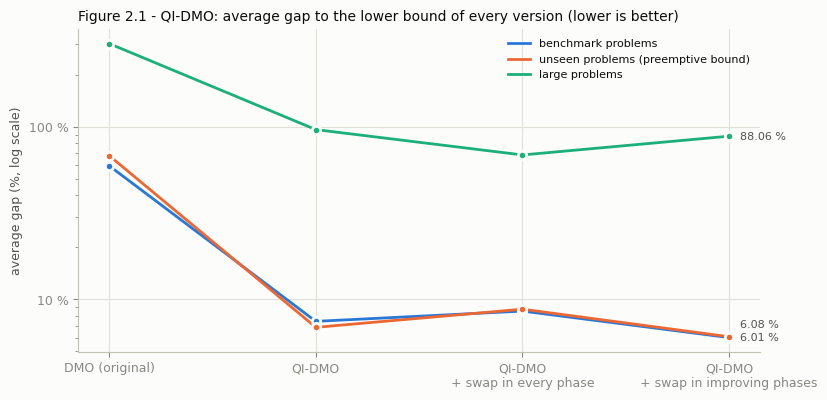

Figure 2.2: gaps below 0.001 % (e.g. an optimal schedule) are drawn at 0.001 %.


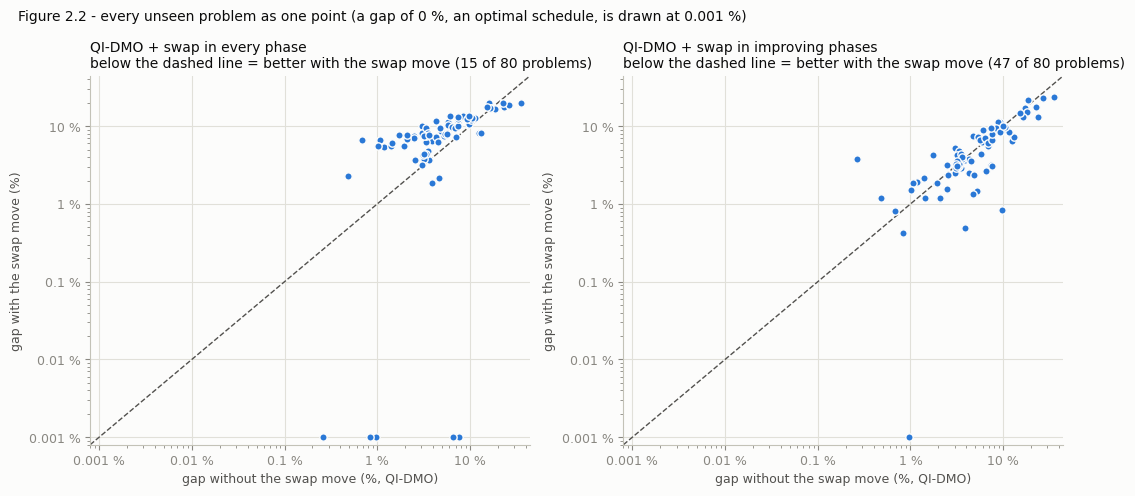

In [14]:
# =====================================================================================================
# PART 2 - HOW QI-DMO WAS IMPROVED, STEP BY STEP
# =====================================================================================================
if RUN_PART_2:
    # ---- run every version on the three problem sets (runs already saved in Part 1 are reused) ---------------
    R = {ps: run_jobs(jobs_for(ps, STEPS), run_one, CSV[ps]) for ps in ["benchmark", "unseen", "large"]}
    B, U, L = R["benchmark"], R["unseen"], R["large"]

    # ---- Tables 2.1-2.3: the mean result of every version on every problem ----------------------------------
    t = B.pivot_table(index="problem", columns="variant", values="makespan_s", aggfunc="mean", sort=False)[STEPS]
    t.insert(0, "lower bound (s)", B.groupby("problem", sort=False).lower_bound_s.first())
    save_table(t.round(3), "2_1_benchmark_versions", "Table 2.1 - benchmark problems: mean makespan (s) of every version")
    per_problem = U.groupby(["problem", "instance_seed", "variant"]).gap_pmtn_pct.mean().unstack("variant")[STEPS]
    t = per_problem.groupby(level=0, sort=False).mean()
    t.loc["ALL unseen problems"] = per_problem.mean()
    save_table(t.round(3), "2_2_unseen_versions",
               "Table 2.2 - unseen problems: mean gap to the (preemptive) lower bound (%) of every version")
    t = L.pivot_table(index="tasks", columns="variant", values="makespan_s", aggfunc="mean")[STEPS]
    t.insert(0, "lower bound (s)", L.groupby("tasks").lower_bound_s.first())
    save_table(t.round(3), "2_3_large_versions", "Table 2.3 - large problems (50 VMs): mean makespan (s) of every version")

    # ---- Table 2.4: what each change gained, on each problem set ---------------------------------------------
    #   benchmark / large: one unit = one problem; test = Mann-Whitney on its runs (Holm across the problems)
    #   unseen:            one unit = one problem (mean of its runs); test = Wilcoxon over the 10 problems of each
    #                      type (Holm across the 8 types), plus one Wilcoxon over all problems ("pooled")
    rows = []
    for after, before in CHANGES:
        for ps, df, col in [("benchmark", B, "gap_pct"), ("unseen", U, "gap_pmtn_pct"), ("large", L, "gap_pct")]:
            if ps == "unseen":
                d_all = per_problem[after] - per_problem[before]
                groups = [(p, d) for p, d in d_all.groupby(level=0, sort=False)]
                diffs, pvals = [d.mean() for _, d in groups], [wilcoxon(d) for _, d in groups]
                units, better, pooled = len(d_all), int((d_all < 0).sum()), wilcoxon(d_all)
                g_before, g_after = per_problem[before].mean(), per_problem[after].mean()
            else:
                diffs, pvals = [], []
                for p, sub in df.groupby("problem", sort=False):
                    xa, xb = sub[sub.variant == after][col], sub[sub.variant == before][col]
                    diffs.append(xa.mean() - xb.mean()); pvals.append(mann_whitney(xa, xb))
                units, better, pooled = len(diffs), int(sum(x < 0 for x in diffs)), float("nan")
                g_before = df[df.variant == before].groupby("problem")[col].mean().mean()
                g_after = df[df.variant == after].groupby("problem")[col].mean().mean()
            ph = holm(np.nan_to_num(pvals, nan=1.0))
            rows.append({"change": f"{before}  ->  {after}", "problem set": ps,
                         "gap before (%)": g_before, "gap after (%)": g_after, "change (percentage points)": g_after - g_before,
                         "better on": f"{better} of {units} problems",
                         "significantly better on": int(sum((x < 0) and (q < 0.05) for x, q in zip(diffs, ph))),
                         "significantly worse on": int(sum((x > 0) and (q < 0.05) for x, q in zip(diffs, ph))),
                         "p (all unseen problems)": p_text(pooled)})
    gains = pd.DataFrame(rows)
    save_table(gains.round(4), "2_4_what_each_change_gained",
               "Table 2.4 - what each change gained (gap = mean over problems; lower is better; unseen problems: "
               "'significantly' counts problem types)")

    # ---- Figure 2.1: average gap of every version, for each problem set --------------------------------------
    fig, ax = plt.subplots(figsize=(8.8, 4.2))
    sets = [("benchmark problems", B, "gap_pct"), ("unseen problems (preemptive bound)", U, "gap_pmtn_pct"),
            ("large problems", L, "gap_pct")]
    ends = []                                                         # last value of each line, for the labels
    for (label, df, col), color in zip(sets, PALETTE):
        y = [df[df.variant == s].groupby("problem")[col].mean().mean() for s in STEPS]
        ax.plot(range(len(STEPS)), y, color=color, linewidth=2, label=label, zorder=2)
        ax.plot(range(len(STEPS)), y, "o", color=color, markersize=6, markeredgecolor=SURFACE, markeredgewidth=2, zorder=3)
        ends.append(y[-1])
    order = np.argsort(ends)
    nudge = np.zeros(len(ends))
    for a, b in zip(order[:-1], order[1:]):                           # labels closer than 15 % would overlap
        if ends[b] < ends[a] * 1.15:
            nudge[b] = nudge[a] + 9
    for v, dy in zip(ends, nudge):
        ax.annotate(f"{v:.2f} %", (len(STEPS) - 1, v), xytext=(8, dy), textcoords="offset points", va="center",
                    fontsize=8, color=INK2)
    ax.set_xticks(range(len(STEPS))); ax.set_xticklabels([s.replace(" + ", "\n+ ").replace(", ", ",\n") for s in STEPS])
    ax.set_yscale("log"); ax.yaxis.set_major_formatter(PERCENT)
    style(ax, f"Figure 2.1 - {MAIN}: average gap to the lower bound of every version (lower is better)",
          "", "average gap (%, log scale)")
    ax.legend(frameon=False, fontsize=8)
    save_figure(fig, "2_1_versions.png")

    # ---- Figure 2.2: every unseen problem - with vs without the swap move ------------------------------------
    fig, axes = plt.subplots(1, len(SCATTER), figsize=(5.4 * len(SCATTER), 5.0), squeeze=False)
    floor = 1e-3                                                      # a gap of 0 % cannot be drawn on a log axis
    if (per_problem.values < floor).any():
        print(f"Figure 2.2: gaps below {floor} % (e.g. an optimal schedule) are drawn at {floor} %.")
    lo = max(floor, per_problem[[v for pair in SCATTER for v in pair]].values.min()) * 0.8
    hi = per_problem[[v for pair in SCATTER for v in pair]].values.max() * 1.25
    for ax, (after, before) in zip(axes[0], SCATTER):
        x, y = np.maximum(per_problem[before].values, floor), np.maximum(per_problem[after].values, floor)
        k = int((per_problem[after] < per_problem[before]).sum())
        ax.scatter(x, y, s=28, color=PALETTE[0], edgecolors=SURFACE, linewidths=1, zorder=3)
        ax.plot([lo, hi], [lo, hi], color=INK2, linewidth=1, linestyle="--", zorder=2)
        ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
        ax.xaxis.set_major_formatter(PERCENT); ax.yaxis.set_major_formatter(PERCENT)
        style(ax, f"{after}\nbelow the dashed line = better with the swap move ({k} of {len(per_problem)} problems)",
              f"gap without the swap move (%, {before})", "gap with the swap move (%)")
    fig.suptitle("Figure 2.2 - every unseen problem as one point (a gap of 0 %, an optimal schedule, is drawn at 0.001 %)",
                 x=0.02, ha="left", fontsize=10, color=INK)
    fig.tight_layout()
    save_figure(fig, "2_2_swap_each_problem.png")
else:
    print("Part 2 skipped (RUN_PART_2 = False).")

## Section 7 — Summary and saved files
* **The summary** is computed from the runs saved in the results folder. A part is summarised only when *all* its runs
  are saved; otherwise the summary says how many runs are missing. It is saved as `summary.txt`.
* **All tables** of this session are also written to one Excel workbook, `all_tables.xlsx`, with one sheet per table.
* **The file list** at the end shows every file in the results folder.

In [15]:
# =====================================================================================================
# SECTION 7 - SUMMARY (computed from the saved runs) AND LIST OF SAVED FILES
# =====================================================================================================
lines = [f"{MAIN} for cloud task scheduling - results summary ({MODE} mode)", f"Folder: {RUN_DIR}",
         f"Written: {time.strftime('%Y-%m-%d %H:%M:%S')}", ""]
if MODE == "quick":
    lines += ["NOTE: quick mode runs a subset of the full runs with the same settings. Each run equals the same run in",
              "full mode, but the averages below use far fewer runs; set MODE = 'full' for the complete results.", ""]


def complete_runs(csv_name, jobs, label):
    # The saved runs of one part if ALL of them are saved, else None (with a note in the summary)
    df = read_runs(csv_name, jobs)
    if df is None or len(df) == 0:
        lines.extend([f"{label}: no saved runs (not run yet).", ""])
        return None
    if len(df) < len(jobs):
        lines.extend([f"{label}: only {len(df)} of {len(jobs)} runs are saved - run its cell again to finish it.", ""])
        return None
    return df


for ps, label in [("benchmark", "Benchmark problems"), ("large", "Large problems (50 VMs)")]:
    df = complete_runs(CSV[ps], jobs_for(ps, [MAIN]), f"Part 1 - {label}")
    if df is not None:
        lines.append(f"Part 1 - {MAIN} on the {label.lower()}: mean makespan (s), best (s), gap (%), run time (s)")
        for p, sub in df.groupby("problem", sort=False):
            lines.append(f"  {p}: {sub.makespan_s.mean():.2f} (best {sub.makespan_s.min():.2f}; lower bound "
                         f"{sub.lower_bound_s.iloc[0]:.2f}), gap {sub.gap_pct.mean():.3f} %, {sub.runtime_s.mean():.1f} s per run")
        lines.append("")

for ps, label, col in [("benchmark", "benchmark problems", "gap_pct"), ("unseen", "unseen problems", "gap_pmtn_pct"),
                       ("large", "large problems", "gap_pct")]:
    df = complete_runs(CSV[ps], jobs_for(ps, STEPS), f"Part 2 - {label}")
    if df is not None:
        lines.append(f"Part 2 - {label}: average gap to the lower bound of every version")
        lines += [f"  {s}: {df[df.variant == s].groupby('problem')[col].mean().mean():.3f} %" for s in STEPS]
        per = df.groupby(["problem", "instance_seed", "variant"])[col].mean().unstack("variant")   # one row per problem
        for after, before in CHANGES:
            d = per[after] - per[before]
            lines.append(f"  {before} -> {after}: better on {int((d < 0).sum())} of {len(d)} problems, worse on "
                         f"{int((d > 0).sum())}" + (f" (Wilcoxon p = {wilcoxon(d):.2g})" if ps == "unseen" else ""))
        lines.append("")

lines += ["Units: makespan in seconds (task length in MI / VM speed in MIPS); energy in Wh; gap in % above the lower bound.",
          "Quantum-inspired = a classical algorithm that uses quantum ideas (registers, measurement, decoherence); no quantum",
          "hardware is used and no quantum advantage is claimed."]
summary = "\n".join(lines)
print(summary)
with open(os.path.join(RUN_DIR, "summary.txt"), "w") as f:
    f.write(summary + "\n")

# All tables of this session in one Excel workbook (one sheet per table)
if ALL_TABLES:
    try:
        with pd.ExcelWriter(os.path.join(RUN_DIR, "all_tables.xlsx")) as xl:
            for name, df in ALL_TABLES.items():
                df.to_excel(xl, sheet_name=name[:31])
    except Exception as err:                         # e.g. openpyxl not installed outside Colab
        print("Excel workbook not written:", err)

print("\nFiles saved in", RUN_DIR)
for fname in sorted(os.listdir(RUN_DIR)):
    print(f"  {fname:36s} {os.path.getsize(os.path.join(RUN_DIR, fname)) / 1024:8.1f} KB")

QI-DMO for cloud task scheduling - results summary (full mode)
Folder: /home/user/QCCProject/results/notebook_runs/QI_DMO_results/full_run
Written: 2026-09-24 06:25:40

Part 1 - QI-DMO on the benchmark problems: mean makespan (s), best (s), gap (%), run time (s)
  30 tasks, 5 VMs, uniform/high: 45.26 (best 44.81; lower bound 44.53), gap 1.648 %, 1.6 s per run
  50 tasks, 10 VMs, bimodal/high: 29.64 (best 26.68; lower bound 25.11), gap 18.036 %, 1.8 s per run
  100 tasks, 10 VMs, uniform/high: 48.93 (best 48.44; lower bound 47.06), gap 3.963 %, 2.4 s per run
  50 tasks, 10 VMs, uniform/none: 30.42 (best 29.67; lower bound 28.39), gap 7.166 %, 2.5 s per run
  200 tasks, 20 VMs, uniform/high: 66.32 (best 64.25; lower bound 60.83), gap 9.017 %, 4.9 s per run
  100 tasks, 10 VMs, lognormal/low: 39.90 (best 39.46; lower bound 38.68), gap 3.165 %, 2.9 s per run
  60 tasks, 8 VMs, bimodal/none: 57.82 (best 55.49; lower bound 52.94), gap 9.233 %, 2.4 s per run

Part 1 - QI-DMO on the large prob

## Section 8 — Finish: write everything to Google Drive
Google Drive receives the files in the background. This last cell makes sure that everything has been written, then
disconnects Drive from this session. To run more cells afterwards, run Section 2 again first.

In [16]:
# =====================================================================================================
# SECTION 8 - MAKE SURE EVERY FILE IS WRITTEN TO GOOGLE DRIVE
# =====================================================================================================
if SAVE_TO_GOOGLE_DRIVE and IN_COLAB:
    from google.colab import drive
    drive.flush_and_unmount()                       # waits until all files are in Google Drive
    print("All results are in Google Drive:", os.path.join("My Drive", DRIVE_FOLDER_NAME, os.path.basename(RUN_DIR)))
else:
    print("Results are in:", RUN_DIR)

Results are in: /home/user/QCCProject/results/notebook_runs/QI_DMO_results/full_run
